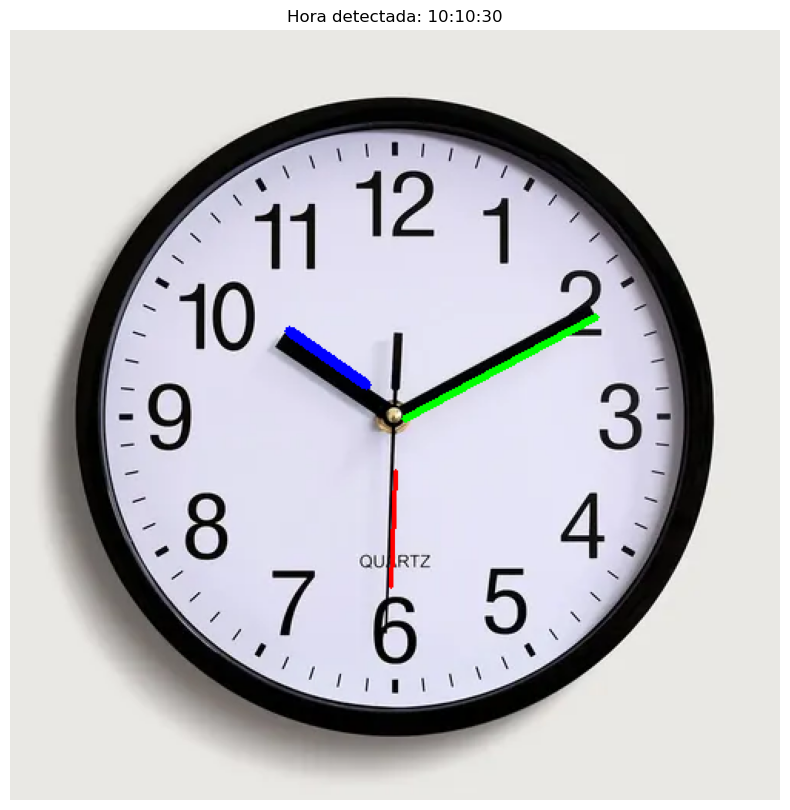

La hora detectada es: 10:10:30
Grosor detectado -> segundero: 5, minutero: 10, horario: 12


In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('pruebareloj13.webp')

imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
gris = cv2.GaussianBlur(gris, (5, 5), 1)
gris = cv2.equalizeHist(gris)

kernel = np.ones((3, 3), np.uint8)
gris = cv2.morphologyEx(gris, cv2.MORPH_OPEN, kernel)

binaria = cv2.adaptiveThreshold(
    gris, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 31, 7
 )

bordes = cv2.Canny(gris, 40, 120)

lineas = cv2.HoughLinesP(
    bordes, 1, np.pi / 180,
    threshold=60,
    minLineLength=35,
    maxLineGap=8
 )

centro_x = imagen_bgr.shape[1] // 2
centro_y = imagen_bgr.shape[0] // 2
radio_origen = 0.22 * min(imagen_bgr.shape[0], imagen_bgr.shape[1])
distancia_maxima_linea = 12

def distancia_punto_segmento(px, py, x1, y1, x2, y2):
    denominador = np.hypot(x2 - x1, y2 - y1)
    if denominador == 0:
        return float('inf')
    return abs((y2 - y1) * px - (x2 - x1) * py + x2 * y1 - y2 * x1) / denominador

def estimar_grosor(mascara, x1, y1, x2, y2):
    centro_x_linea = int(round((x1 + x2) / 2))
    centro_y_linea = int(round((y1 + y2) / 2))
    dx = x2 - x1
    dy = y2 - y1
    longitud = np.hypot(dx, dy)
    if longitud == 0:
        return 0

    ux = -dy / longitud
    uy = dx / longitud
    ventana = 14
    perfil = []

    for paso in range(-ventana, ventana + 1):
        x = int(round(centro_x_linea + ux * paso))
        y = int(round(centro_y_linea + uy * paso))
        if 0 <= y < mascara.shape[0] and 0 <= x < mascara.shape[1]:
            perfil.append(mascara[y, x] > 0)
        else:
            perfil.append(False)

    mejor = 0
    actual = 0
    for valor in perfil:
        if valor:
            actual += 1
            mejor = max(mejor, actual)
        else:
            actual = 0

    return mejor

manecillas = []
if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]

        d1 = np.hypot(x1 - centro_x, y1 - centro_y)
        d2 = np.hypot(x2 - centro_x, y2 - centro_y)

        if d1 <= d2:
            x_cerca, y_cerca, d_near = x1, y1, d1
            x_lejos, y_lejos, d_far = x2, y2, d2
        else:
            x_cerca, y_cerca, d_near = x2, y2, d2
            x_lejos, y_lejos, d_far = x1, y1, d1

        if d_near > radio_origen or d_far < 40:
            continue

        distancia_centro = distancia_punto_segmento(
            centro_x, centro_y, x1, y1, x2, y2
        )
        if distancia_centro > distancia_maxima_linea:
            continue

        grosor = estimar_grosor(binaria, x1, y1, x2, y2)
        if grosor == 0:
            continue

        dx = x_lejos - centro_x
        dy = centro_y - y_lejos
        angulo = np.degrees(np.arctan2(dy, dx))
        angulo = (90 - angulo) % 360

        manecillas.append({
            'puntos': (x_cerca, y_cerca, x_lejos, y_lejos),
            'longitud': d_far,
            'grosor': grosor,
            'angulo': angulo,
            'distancia_centro': distancia_centro
        })

manecillas_agrupadas = []
for m in sorted(manecillas, key=lambda x: (x['angulo'], x['distancia_centro'], -x['grosor'])):
    agrupado = False
    for grupo in manecillas_agrupadas:
        diff = abs(grupo['angulo'] - m['angulo'])
        diff = min(diff, 360 - diff)

        if diff < 12:
            if (m['grosor'] > grupo['grosor'] or
                (m['grosor'] == grupo['grosor'] and m['longitud'] > grupo['longitud'])):
                grupo['longitud'] = m['longitud']
                grupo['puntos'] = m['puntos']
                grupo['angulo'] = m['angulo']
                grupo['distancia_centro'] = m['distancia_centro']
                grupo['grosor'] = m['grosor']
            agrupado = True
            break

    if not agrupado:
        manecillas_agrupadas.append(dict(m))

if len(manecillas_agrupadas) >= 3:
    manecillas_agrupadas.sort(key=lambda x: (x['grosor'], x['longitud']))
    segundero = manecillas_agrupadas[0]
    minutero = manecillas_agrupadas[1]
    horario = manecillas_agrupadas[2]

    hora_float = (horario['angulo'] / 30) % 12
    hora = int(hora_float)
    if abs(hora_float - hora) > 0.5:
        hora = (hora + 1) % 12
    if hora == 0:
        hora = 12

    minutos = int((minutero['angulo'] / 6) % 60)
    segundos = int((segundero['angulo'] / 6) % 60)

    imagen_resultado = imagen_rgb.copy()

    cv2.line(imagen_resultado,
             (horario['puntos'][0], horario['puntos'][1]),
             (horario['puntos'][2], horario['puntos'][3]),
             (0, 0, 255), 5)
    cv2.line(imagen_resultado,
             (minutero['puntos'][0], minutero['puntos'][1]),
             (minutero['puntos'][2], minutero['puntos'][3]),
             (0, 255, 0), 4)
    cv2.line(imagen_resultado,
             (segundero['puntos'][0], segundero['puntos'][1]),
             (segundero['puntos'][2], segundero['puntos'][3]),
             (255, 0, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_resultado)
    plt.title(f'Hora detectada: {hora}:{minutos:02d}:{segundos:02d}')
    plt.axis('off')
    plt.show()

    print(f'La hora detectada es: {hora}:{minutos:02d}:{segundos:02d}')
    print(f'Grosor detectado -> segundero: {segundero["grosor"]}, minutero: {minutero["grosor"]}, horario: {horario["grosor"]}')
else:
    print('No se detectaron suficientes manecillas :(')